In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from GASModels.dynamics import Dynamics
from GASModels.distributions.gamma_log_link import GammaLogLinkDistribution

In [2]:
xls = pd.read_excel('data/Energia Sudeste.xls')

In [3]:
# Create dynamics object
dynamics = Dynamics(
    distribution=GammaLogLinkDistribution(),
    n=len(xls['energia']),
    trend=None,
    seasonality=None,
    harmonics=6,
    period=12,
    time_varying_indices=[0],
    fixed_params_indices=[1],
    args=[0.05, 0.02]
)


In [4]:
initial_params = dynamics.get_initial_values(xls['energia'])

In [5]:
initial_params

array([2.        , 2.        , 2.        , 2.        , 2.        ,
       2.        , 2.        , 2.        , 2.        , 2.        ,
       2.        , 2.        , 2.        , 2.        , 8.63462061,
       0.        ])

In [6]:

# Define bounds
bounds = [
    (-20000, 20000),    # km
    (-20000, 20000),    # kg
    *[(None, None) for _ in range(13)],
    (None,None)
]

# Run optimization
result = minimize(
    dynamics.objective,
    x0=initial_params,
    args=(xls['energia'],),
    method='BFGS',
    options={'gtol': 1e-1, 'maxiter': 10000}
)

c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gamma_log_link.py:21: RuntimeWarning: overflow encountered in exp
  scale = np.exp(lambda_ - alpha)  # theta = exp(lambda - alpha)
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gamma_log_link.py:49: RuntimeWarning: overflow encountered in exp
  dL_dlambda = np.exp(alpha) * (y / np.exp(lambda_) - 1)
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gamma_log_link.py:56: RuntimeWarning: overflow encountered in exp
  - y / np.exp(lambda_)
c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2106: RuntimeWarning: divide by zero encount

In [7]:
result

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 2824.6175766784836
        x: [ 7.910e+00 -1.852e-02 ...  8.632e+00  6.670e+00]
      nit: 26
      jac: [-2.106e-03 -9.061e-02 ...  1.382e-02 -4.324e-02]
 hess_inv: [[ 6.560e-01 -1.657e-03 ...  9.951e-04 -4.031e-02]
            [-1.657e-03  6.664e-05 ...  5.915e-06  1.301e-04]
            ...
            [ 9.951e-04  5.915e-06 ...  1.312e-03 -7.947e-05]
            [-4.031e-02  1.301e-04 ... -7.947e-05  5.436e-03]]
     nfev: 741
     njev: 43

In [8]:
dynamics.objective(result['x'], xls['energia'])

np.float64(2824.6175766784836)

In [9]:
result['x']

array([  7.9098661 ,  -0.01852481,  -0.13668107, -13.74342803,
         4.45205863,  -0.50164768,   5.47681024,   1.10307786,
        -4.4607918 ,   0.38014942,  -2.91044743,   3.15752882,
         8.43209586,   0.0419173 ,   8.63209675,   6.67046262])

In [10]:
result['jac']

array([-2.10571289e-03, -9.06066895e-02,  5.79833984e-04, -1.73950195e-03,
       -1.40380859e-03,  5.18798828e-04, -5.49316406e-04,  1.37329102e-03,
        2.86865234e-03, -2.86865234e-03, -2.34985352e-03,  9.15527344e-05,
       -4.88281250e-04,  8.23974609e-04,  1.38244629e-02, -4.32434082e-02])

In [11]:
fis = result['x']

In [14]:
fis

array([  7.9068272 ,  -0.01854502,  -0.17994326, -13.7653389 ,
         4.39878499,  -0.53799654,   5.40999381,   0.9686162 ,
        -4.46792417,   0.35518207,  -2.93031217,   3.12640097,
         8.38451151,   0.06659359,   8.63213662,   6.6707251 ])

In [12]:
y = dynamics.fit_in_sample(fis, xls['energia'])

In [16]:
y

array([ 5606.97158326,  5613.09083636,  5576.88469503,  5683.42271886,
        5743.87582277,  5901.37412349,  5947.00495341,  6029.16844906,
        6036.39518389,  6226.26565465,  6186.97822317,  6293.73757716,
        6329.017617  ,  6291.96867977,  6264.57158694,  6278.25488983,
        6339.1603798 ,  6404.27707785,  6493.37930547,  6492.18299221,
        6751.39791289,  6778.34144831,  6808.61474154,  6992.38173644,
        6786.36457896,  7009.81050459,  6746.35982013,  6842.85613264,
        6637.82768003,  6697.65454812,  6545.64703277,  6584.80716062,
        6739.75034723,  6614.03791861,  6626.77776878,  6668.57276018,
        6556.98594698,  6632.3130265 ,  6477.58086582,  6543.76305504,
        6987.35602553,  6881.18657043,  6948.77241948,  7046.88832507,
        7200.09337093,  7297.21605962,  7258.95737285,  7231.56544704,
        7144.31414169,  7130.1394748 ,  6983.16577865,  6946.18834169,
        7374.22437168,  7238.05551337,  7590.90666296,  7475.80918962,
      

In [ ]:
np.exp(0.998) * (y / np.exp(9.953) - 1)

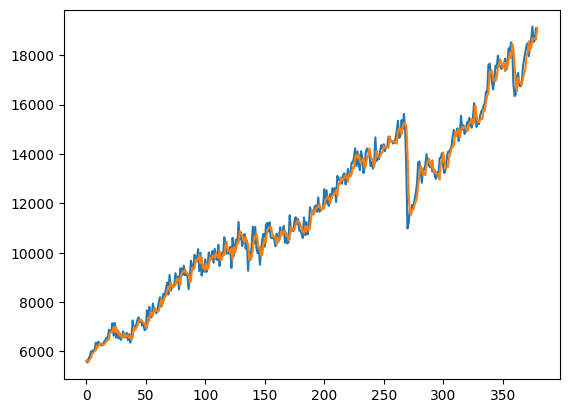

In [13]:
plt.plot(xls['energia'])
plt.plot(y)

In [8]:
y = dynamics.fit_in_sample([2.927e-02, 9.953, 0.998], xls['energia'])